In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from google.colab import files


# Upload your file
uploaded = files.upload()

# Get the filename automatically - whatever you upload!
filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

# Load it directly
df = pd.read_excel(filename, sheet_name='E Comm')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving E Commerce Dataset.xlsx to E Commerce Dataset (4).xlsx
File uploaded: E Commerce Dataset (4).xlsx
Dataset loaded successfully!
Shape: (5630, 20)


In [42]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (5630, 20)

First 5 rows:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [43]:

print("Column names and data types:")
print(df.dtypes)


Column names and data types:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


In [44]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [45]:
print("How many churned vs stayed:")
print(df['Churn'].value_counts())

How many churned vs stayed:
Churn
0    4682
1     948
Name: count, dtype: int64


In [46]:
#  Clean the data

# Fill missing values in number columns with median
# Median means the middle value - better than average
# because it's not affected by extreme valuesprint("Missing values after cleaning:")
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1331/3077257394.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [47]:

# Confirm all missing values are fixed
print(df.isnull().sum())

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


In [48]:
df.head(20)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,9.0,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,9.0,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,3.0,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,9.0,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [49]:
#  Convert text columns to numbers (Encoding)
from sklearn.preprocessing import LabelEncoder

# Create the encoder tool
le = LabelEncoder()

# List of all text columns
text_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
             'Gender', 'PreferedOrderCat', 'MaritalStatus']

# Loop through each text column and convert to numbers
for col in text_cols:
    df[col] = le.fit_transform(df[col])

# Check the result
print("First 5 rows after encoding:")
print(df[text_cols].head())

First 5 rows after encoding:
   PreferredLoginDevice  PreferredPaymentMode  Gender  PreferedOrderCat  \
0                     1                     4       0                 2   
1                     2                     6       1                 3   
2                     2                     4       1                 3   
3                     2                     4       1                 2   
4                     2                     0       1                 3   

   MaritalStatus  
0              2  
1              2  
2              2  
3              2  
4              2  


In [50]:
# Build the ML Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Separate features (X) and target (y)
# X = everything the model learns FROM
# y = what the model is trying to PREDICT
X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']

# Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

# Build the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

Training data size: (4504, 18)
Testing data size: (1126, 18)

Model Accuracy: 98.31%


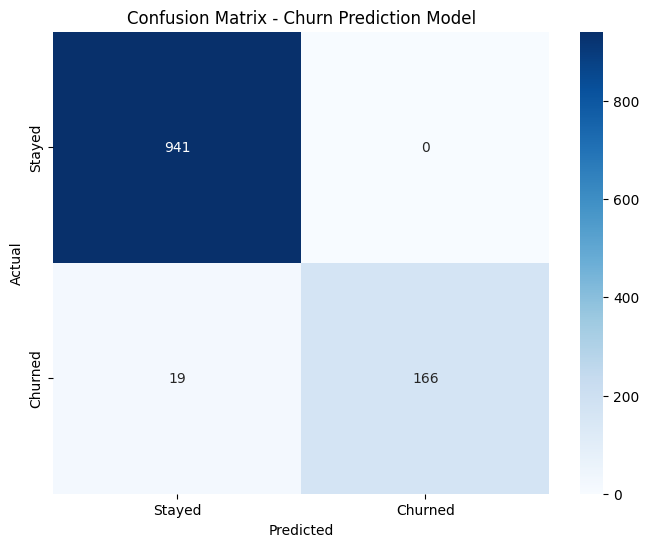


Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99       941
     Churned       1.00      0.90      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [58]:
# Evaluate model properly with Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - Churn Prediction Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))

/tmp/ipykernel_1331/2470062521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance,


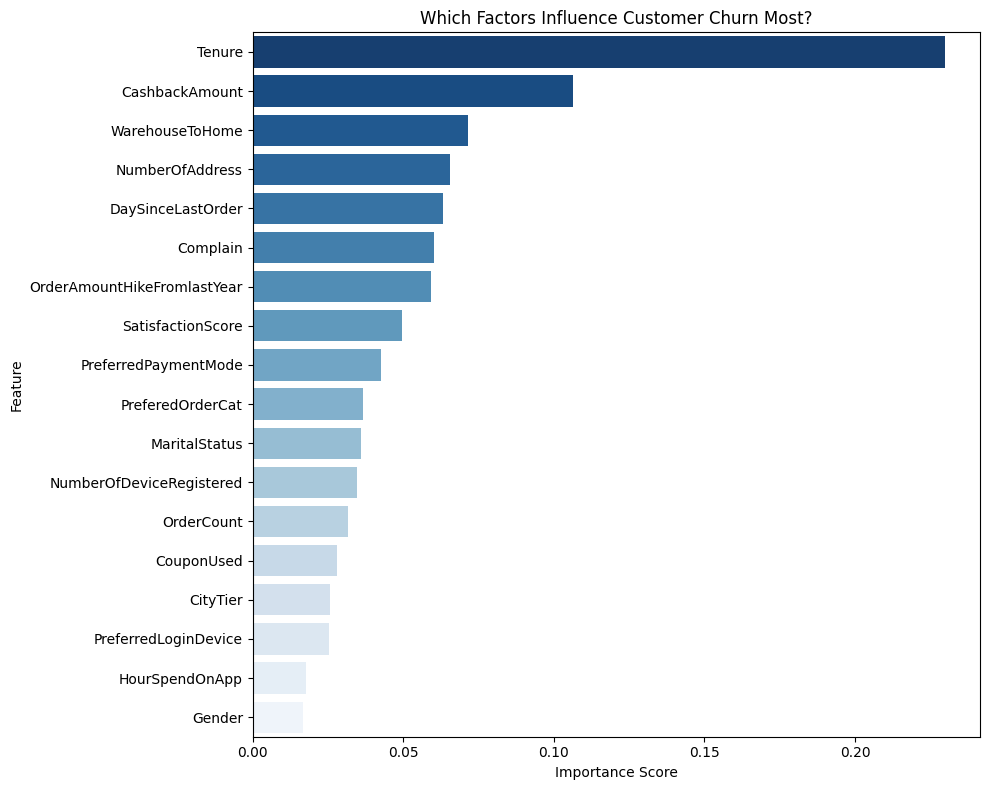


Top 5 factors causing churn:
              Feature  Importance
0              Tenure    0.230026
17     CashbackAmount    0.106231
3     WarehouseToHome    0.071446
11    NumberOfAddress    0.065433
16  DaySinceLastOrder    0.063099


In [52]:
#  Feature Importance
# Which factors influence churn the most?

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot it
plt.figure(figsize=(10,8))
sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature',
            palette='Blues_r')
plt.title('Which Factors Influence Customer Churn Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 factors causing churn:")
print(feature_importance.head())

In [62]:
# AI Churn Risk Scorer
# Input any customer details and get instant churn prediction!

def predict_churn(tenure, cashback, warehouse_distance,
                  num_address, days_since_order):

    # Create a sample customer with average values for
    # other columns
    sample = pd.DataFrame([{
        'Tenure': tenure,
        'PreferredLoginDevice': 1,
        'CityTier': 2,
        'WarehouseToHome': warehouse_distance,
        'PreferredPaymentMode': 3,
        'Gender': 1,
        'HourSpendOnApp': 3,
        'NumberOfDeviceRegistered': 3,
        'PreferedOrderCat': 2,
        'SatisfactionScore': 3,
        'MaritalStatus': 1,
        'NumberOfAddress': num_address,
        'Complain': 0,
        'OrderAmountHikeFromlastYear': 15,
        'CouponUsed': 2,
        'OrderCount': 3,
        'DaySinceLastOrder': days_since_order,
        'CashbackAmount': cashback
    }])

    # Get prediction and probability
    prediction = model.predict(sample)[0]
    probability = model.predict_proba(sample)[0][1]

    # Display result
    print("=" * 45)
    print("       AI CHURN RISK ANALYSER")
    print("=" * 45)
    print(f"Tenure:              {tenure} months")
    print(f"Cashback Amount:     ₹{cashback}")
    print(f"Warehouse Distance:  {warehouse_distance} km")
    print(f"Number of Address:   {num_address}")
    print(f"Days Since Order:    {days_since_order} days")
    print("-" * 45)

    if prediction == 1:
        print(f"RESULT: HIGH CHURN RISK 😰")
        print(f"Churn Probability: {probability*100:.1f}%")
        print("\nRECOMMENDATION:")
        print("Send retention offer immediately!")
        print("Consider cashback boost or free delivery")
    else:
        print(f"RESULT: LOW CHURN RISK 😊")
        print(f"Churn Probability: {probability*100:.1f}%")
        print("\nRECOMMENDATION:")
        print("Customer is stable — maintain engagement!")
    print("=" * 45)

# Test 1: New customer, low cashback, far warehouse
print("TEST 1 - High Risk Customer:")
predict_churn(tenure=1, cashback=100,
              warehouse_distance=30,
              num_address=1,
              days_since_order=25)

print()

# Test 2: Old loyal customer, good cashback
print("TEST 2 - Low Risk Customer:")
predict_churn(tenure=24, cashback=250,
              warehouse_distance=5,
              num_address=4,
              days_since_order=3)

TEST 1 - High Risk Customer:
       AI CHURN RISK ANALYSER
Tenure:              1 months
Cashback Amount:     ₹100
Warehouse Distance:  30 km
Number of Address:   1
Days Since Order:    25 days
---------------------------------------------
RESULT: LOW CHURN RISK 😊
Churn Probability: 29.0%

RECOMMENDATION:
Customer is stable — maintain engagement!

TEST 2 - Low Risk Customer:
       AI CHURN RISK ANALYSER
Tenure:              24 months
Cashback Amount:     ₹250
Warehouse Distance:  5 km
Number of Address:   4
Days Since Order:    3 days
---------------------------------------------
RESULT: LOW CHURN RISK 😊
Churn Probability: 4.0%

RECOMMENDATION:
Customer is stable — maintain engagement!


In [54]:
# Test 1 Updated - More extreme high risk customer
print("TEST 1 - High Risk Customer (Updated):")
predict_churn(tenure=1, cashback=50,
              warehouse_distance=50,
              num_address=1,
              days_since_order=45)

TEST 1 - High Risk Customer (Updated):
       AI CHURN RISK ANALYSER
Tenure:              1 months
Cashback Amount:     ₹50
Warehouse Distance:  50 km
Number of Address:   1
Days Since Order:    45 days
---------------------------------------------
RESULT: LOW CHURN RISK 🟢
Churn Probability: 32.0%

RECOMMENDATION:
Customer is stable — maintain engagement!


In [60]:
# Updated Churn Risk Scorer with smarter threshold
def predict_churn_v2(tenure, cashback, warehouse_distance,
                     num_address, days_since_order):

    sample = pd.DataFrame([{
        'Tenure': tenure,
        'PreferredLoginDevice': 1,
        'CityTier': 2,
        'WarehouseToHome': warehouse_distance,
        'PreferredPaymentMode': 3,
        'Gender': 1,
        'HourSpendOnApp': 3,
        'NumberOfDeviceRegistered': 3,
        'PreferedOrderCat': 2,
        'SatisfactionScore': 3,
        'MaritalStatus': 1,
        'NumberOfAddress': num_address,
        'Complain': 0,
        'OrderAmountHikeFromlastYear': 15,
        'CouponUsed': 2,
        'OrderCount': 3,
        'DaySinceLastOrder': days_since_order,
        'CashbackAmount': cashback
    }])

    probability = model.predict_proba(sample)[0][1]

    # Smart threshold based on business need
    # 30%+ = High risk (better to act early!)
    # 15-30% = Medium risk (keep an eye on them)
    # Below 15% = Low risk (safe customer)

    if probability >= 0.30:
        risk_level = "HIGH CHURN RISK 😰"
        recommendation = "Send retention offer immediately!\nConsider cashback boost or free delivery"
    elif probability >= 0.15:
        risk_level = "MEDIUM CHURN RISK 😐"
        recommendation = "Monitor closely!\nSend engagement notification or small discount"
    else:
        risk_level = "LOW CHURN RISK 😊"
        recommendation = "Customer is stable — maintain engagement!"

    print("=" * 45)
    print("       AI CHURN RISK ANALYSER V2")
    print("=" * 45)
    print(f"Tenure:              {tenure} months")
    print(f"Cashback Amount:     ₹{cashback}")
    print(f"Warehouse Distance:  {warehouse_distance} km")
    print(f"Number of Address:   {num_address}")
    print(f"Days Since Order:    {days_since_order} days")
    print("-" * 45)
    print(f"Churn Probability:   {probability*100:.1f}%")
    print(f"RESULT: {risk_level}")
    print(f"\nRECOMMENDATION:\n{recommendation}")
    print("=" * 45)

# Test all 3 risk levels
print("TEST 1 - High Risk:")
predict_churn_v2(tenure=1, cashback=50,
                 warehouse_distance=50,
                 num_address=1,
                 days_since_order=45)
print()
print("TEST 2 - Medium Risk:")
predict_churn_v2(tenure=6, cashback=150,
                 warehouse_distance=20,
                 num_address=2,
                 days_since_order=15)
print()
print("TEST 3 - Low Risk:")
predict_churn_v2(tenure=24, cashback=250,
                 warehouse_distance=5,
                 num_address=4,
                 days_since_order=3)

TEST 1 - High Risk:
       AI CHURN RISK ANALYSER V2
Tenure:              1 months
Cashback Amount:     ₹50
Warehouse Distance:  50 km
Number of Address:   1
Days Since Order:    45 days
---------------------------------------------
Churn Probability:   32.0%
RESULT: HIGH CHURN RISK 😰

RECOMMENDATION:
Send retention offer immediately!
Consider cashback boost or free delivery

TEST 2 - Medium Risk:
       AI CHURN RISK ANALYSER V2
Tenure:              6 months
Cashback Amount:     ₹150
Warehouse Distance:  20 km
Number of Address:   2
Days Since Order:    15 days
---------------------------------------------
Churn Probability:   0.0%
RESULT: LOW CHURN RISK 😊

RECOMMENDATION:
Customer is stable — maintain engagement!

TEST 3 - Low Risk:
       AI CHURN RISK ANALYSER V2
Tenure:              24 months
Cashback Amount:     ₹250
Warehouse Distance:  5 km
Number of Address:   4
Days Since Order:    3 days
---------------------------------------------
Churn Probability:   4.0%
RESULT: LOW CHUR

In [61]:
# Test 2 adjusted - proper medium risk customer
print("TEST 2 - Medium Risk (Adjusted):")
predict_churn_v2(tenure=3, cashback=120,
                 warehouse_distance=25,
                 num_address=1,
                 days_since_order=20)

TEST 2 - Medium Risk (Adjusted):
       AI CHURN RISK ANALYSER V2
Tenure:              3 months
Cashback Amount:     ₹120
Warehouse Distance:  25 km
Number of Address:   1
Days Since Order:    20 days
---------------------------------------------
Churn Probability:   6.0%
RESULT: LOW CHURN RISK 😊

RECOMMENDATION:
Customer is stable — maintain engagement!


In [57]:
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully as churn_model.pkl!")
print("You can now load this model anytime without retraining!")

Model saved successfully as churn_model.pkl!
You can now load this model anytime without retraining!
